In [13]:
from pathlib import Path
import numpy as np
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
from scipy.signal import welch

def most_powerful_band(x, sr, bands=None, nperseg=4096, noverlap=None, averaging="mean"):
    """
    x: np.ndarray, shape (T,) or (C, T)
    sr: sampling rate (Hz)
    bands: list of (f_low, f_high) in Hz. If None -> 10 log-spaced bands.
    averaging: "mean" or "sum" power within band
    """
    x = np.asarray(x)
    if x.ndim == 1:
        x = x[None, :]  # -> (1, T)
    C, T = x.shape

    # PSD per channel
    f, Pxx = welch(x, fs=sr, axis=-1, nperseg=nperseg, noverlap=noverlap)  # shape: (C, F)

    # default: 10 log-spaced bands from 20 Hz to Nyquist
    if bands is None:
        fmin, fmax = max(20, f[1]), f[-1]
        edges = np.geomspace(fmin, fmax, 11)  # 10 bands
        bands = list(zip(edges[:-1], edges[1:]))

    band_powers = []
    for (fl, fh) in bands:
        m = (f >= fl) & (f < fh)
        if not np.any(m):
            band_powers.append(np.zeros(C))
            continue
        band_power = Pxx[:, m].mean(axis=1) if averaging == "mean" else Pxx[:, m].sum(axis=1)
        band_powers.append(band_power)

    band_powers = np.stack(band_powers, axis=0)  # (B, C)
    # pick band with max power per channel
    idx_max = band_powers.argmax(axis=0)         # (C,)
    best_bands = [bands[i] for i in idx_max]
    best_vals  = band_powers[idx_max, range(C)]

    # also report single peak frequency per channel
    peak_idx = Pxx.argmax(axis=1)
    peak_freqs = f[peak_idx]

    return {
        "bands": bands,
        "band_powers": band_powers,   # (B, C)
        "best_band_per_channel": best_bands,
        "best_band_power": best_vals,
        "peak_freq_per_channel": peak_freqs
    }


def load_mono(path, sr=None, offset=None, duration=None):
    y, sr = librosa.load(path, sr=sr, mono=True, offset=offset, duration=duration)  # to mono, optional resample
    return y, sr

def make_same_length(a, b, mode="min"):
    if mode == "min":
        while len(b ) < len(a):
            b = np.concatenate((b, b))
        if len(a ) < len(b):
            L = min(len(a), len(b))
        else:
            raise ValueError("Unexpected length comparison.")
        
        return a[:L], b[:L]
    elif mode == "max":
        L = max(len(a), len(b))
        a2 = np.pad(a, (0, L - len(a)))
        b2 = np.pad(b, (0, L - len(b)))
        return a2, b2
    else:
        raise ValueError("mode must be 'min' or 'max'")

def normalize_peak(y, peak=0.99):
    m = np.max(np.abs(y))
    return y if m == 0 else y * (peak / m)

def mix_two_sources_to_five(
    wav1, wav2, offset2=None, duration2=None, sr_target=None, out_dir=None, A=None, length_mode="min", add_noise_std=0.0
):
    # 1) Load
    s1, sr1 = load_mono(wav1, sr=sr_target)
    s2, sr2 = load_mono(wav2,offset=offset2, duration=duration2, sr=sr_target if sr_target is not None else sr1)

    # 2) Ensure same SR
    if sr_target is None and sr1 != sr2:
        # resample second to first if needed
        s2 = librosa.resample(s2, orig_sr=sr2, target_sr=sr1)
        sr = sr1
    else:
        sr = sr_target if sr_target is not None else sr1

    # 3) Match length
    s1, s2 = make_same_length(s1, s2, mode=length_mode)

    # 4) Stack sources: s has shape (2, T)
    s = np.vstack([s1[np.newaxis, :], s2[np.newaxis, :]])

    # 5) Choose/define a well-conditioned 5×2 mixing matrix A
    if A is None:
        raise ValueError("A is not defined")

    x = A @ s

    # 7) Optional noise
    if add_noise_std > 0:
        x = x + np.random.randn(*x.shape) * add_noise_std

    # 8) Normalize per-mixture to avoid clipping, keep float32
    for i in range(x.shape[0]):
        x[i] = normalize_peak(x[i], peak=0.99)
    x = x.astype(np.float32)

    # 9) Save (optional)
    paths = []
    if out_dir is not None:
        out = Path(out_dir); out.mkdir(parents=True, exist_ok=True)
        for i in range(5):
            p = out / f"mix_{i+1}.wav"
            sf.write(p.as_posix(), x[i], sr, subtype="PCM_16")  # or 'FLOAT'
            paths.append(p.as_posix())

    return x, sr, A, paths

def plot_fft(signals, sr, title_prefix):
    n = signals.shape[0]
    freq = np.fft.rfftfreq(n, d=1/sr)
    plt.figure(figsize=(14, 8))
    for i in range(signals.shape[1]):
        fft_vals = np.fft.rfft(signals[:, i])
        plt.subplot(signals.shape[1], 1, i+1)
        plt.plot(freq, np.abs(fft_vals))
        plt.title(f"{title_prefix} {i+1} - Magnitude Spectrum")
        plt.xlabel("Frequency [Hz]")
        plt.ylabel("Magnitude")
    plt.tight_layout()
    plt.show()

def plot_waveforms(signals, sr, title_prefix):
    time = np.arange(signals.shape[0]) / sr
    plt.figure(figsize=(14, 8))
    for i in range(signals.shape[1]):
        plt.subplot(signals.shape[1], 1, i+1)
        plt.plot(time, signals[:, i])
        plt.title(f"{title_prefix} {i+1} - Waveform")
        plt.xlabel("Time [s]")
        plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()



In [4]:
# Define load original signals

folder = "dataset/"
aircraft_path = folder + "Gardemoen/Clip2/A2-0002_OPT_G_002_0001_Tr2.wav"
wind_path = folder + "438866__craigsmith__g55-12-moaning-whistle-wind.wav"

s1, sr1 = load_mono(aircraft_path)
s2, sr2 = load_mono(wind_path, duration=31, offset=2.5)
s1 = normalize_peak(s1)
s2 = normalize_peak(s2) 


Shifted wind source saved to dataset/synthetic_data/wind_shifted.wav with +15 semitones.


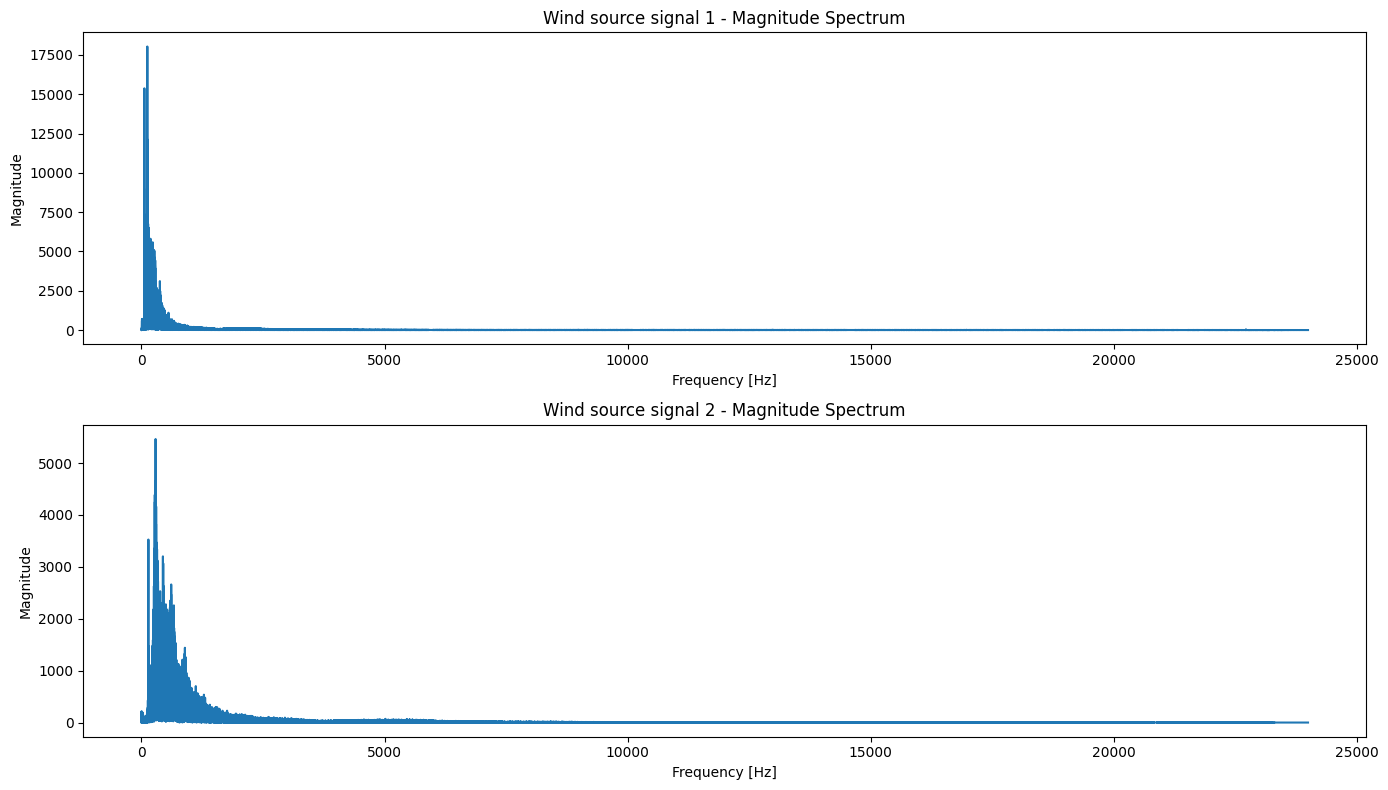

In [5]:
# Create a higher-pitched version of the wind source 

n_steps = 15
s2_shifted = librosa.effects.pitch_shift(y=s2, sr=sr2, n_steps=n_steps)
sf.write("dataset/synthetic_data/wind_shifted.wav", s2_shifted, sr2)
s2_array = np.vstack([s2[np.newaxis, :], s2_shifted[np.newaxis, :]])

print(f'Shifted wind source saved to dataset/synthetic_data/wind_shifted.wav with +{n_steps} semitones.')

plot_fft(s2_array.transpose(), sr2, "Wind source signal")

In [6]:
# Analyse frequency bands

res1 = most_powerful_band(s1, sr1)  # signals shape (2, 1488000)
print("Best band ch1:", res1["best_band_per_channel"][0], "Peak freq:", res1["peak_freq_per_channel"][0])

res2 = most_powerful_band(s2, sr2)  # signals shape (2, 1488000)
print("Best band ch1:", res2["best_band_per_channel"][0], "Peak freq:", res2["peak_freq_per_channel"][0])

res3 = most_powerful_band(s2_shifted, sr2)  # signals shape (2, 1488000)
print("Best band ch1:", res3["best_band_per_channel"][0], "Peak freq:", res3["peak_freq_per_channel"][0])

Best band ch1: (167.79706860217857, 340.95926336153053) Peak freq: 281.25
Best band ch1: (82.57835834666739, 167.79706860217857) Peak freq: 117.1875
Best band ch1: (167.79706860217857, 340.95926336153053) Peak freq: 281.25


In [19]:
# Generate synthetic mixtures Part 1
snr = [10, 5, 1, 0.5, -0.5]
theta1s = [1.0]* len(snr)
theta2s = snr

A=np.column_stack([theta1s, theta2s])

X1, sr, A1, paths1 = mix_two_sources_to_five(
    wav1=aircraft_path,
    wav2=wind_path,
    offset2=2.5,  
    duration2=31.0,    
    sr_target=None,          # or None to keep native SR
    out_dir="dataset/synthetic_data",
    A= A,                   # or supply your own 5x2
    length_mode="min",        # truncate to the shorter source
    add_noise_std=0.0         # e.g., 0.005 for light noise
)

print("Mixtures shape:", X1.shape)  # (5, T)
print("SR:", sr)
print("A:\n", A1)
print("Saved:", paths1)

Mixtures shape: (5, 3571568)
SR: 48000
A:
 [[ 1.  10. ]
 [ 1.   5. ]
 [ 1.   1. ]
 [ 1.   0.5]
 [ 1.  -0.5]]
Saved: ['dataset/synthetic_data/mix_1.wav', 'dataset/synthetic_data/mix_2.wav', 'dataset/synthetic_data/mix_3.wav', 'dataset/synthetic_data/mix_4.wav', 'dataset/synthetic_data/mix_5.wav']


In [ ]:
# Generate synthetic mixtures Part 2

X2, sr, A2, paths2 = mix_two_sources_to_five(
    wav1=aircraft_path,
    wav2='dataset/synthetic_data/wind_shifted.wav',
    offset2=2.5,  
    duration2=31.0,    
    sr_target=None,          # or None to keep native SR
    out_dir="dataset/synthetic_data/Part2",
    A=np.array([
        [0.9, 0.1],
        [0.7, 0.3],
        [0.5, 0.5],
        [0.3, 0.7],
        [0.1, 0.9],
    ], dtype=np.float32),                   # or supply your own 5x2
    length_mode="min",        # truncate to the shorter source
    add_noise_std=0.0         # e.g., 0.005 for light noise
)

X3, sr, A3, paths3 = mix_two_sources_to_five(
    wav1=aircraft_path,
    wav2='dataset/synthetic_data/wind_shifted.wav',
    offset2=2.5,  
    duration2=31.0,    
    sr_target=None,          # or None to keep native SR
    out_dir="dataset/synthetic_data/Part2",
    A=np.array([
        [0.8, 0.2],
        [0.6, 0.4],
        [0.4, 0.6],
        [0.2, 0.8],
        [0.1, 0.9],
    ], dtype=np.float32),                   # or supply your own 5x2
    length_mode="min",        # truncate to the shorter source
    add_noise_std=0.0         # e.g., 0.005 for light noise
)

print("Mixtures shape:", X3.shape)  # (5, T)
print("SR:", sr)
print("A:\n", A3)
print("Saved:", paths3)

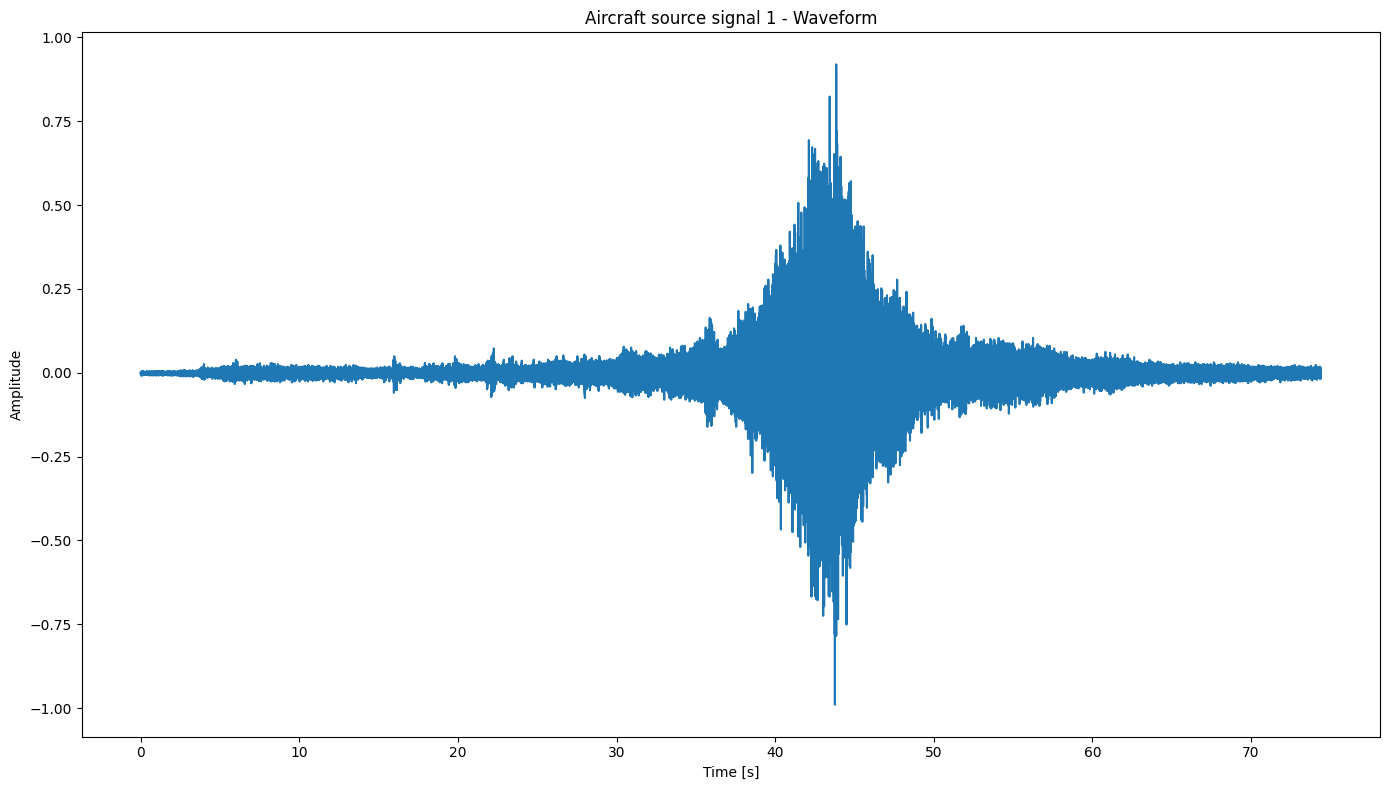

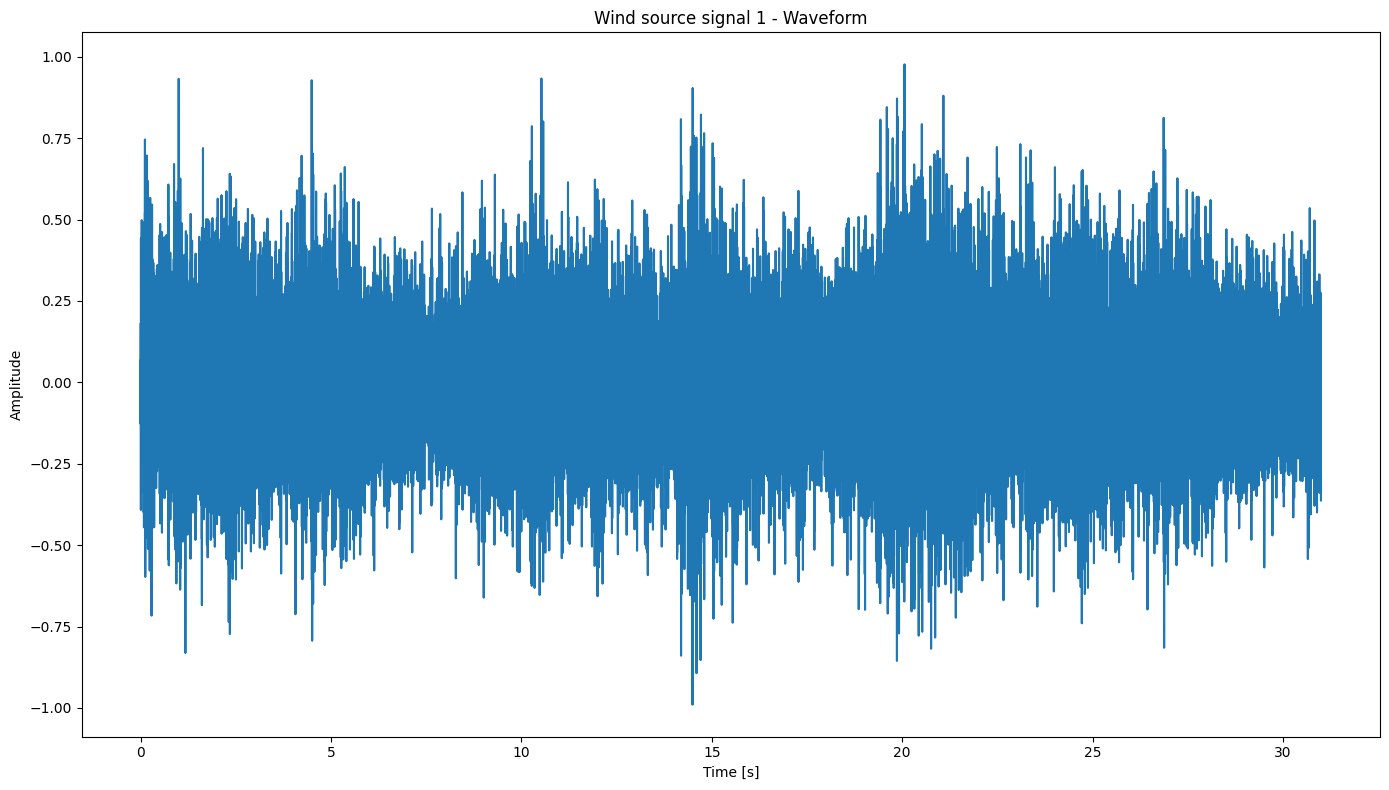

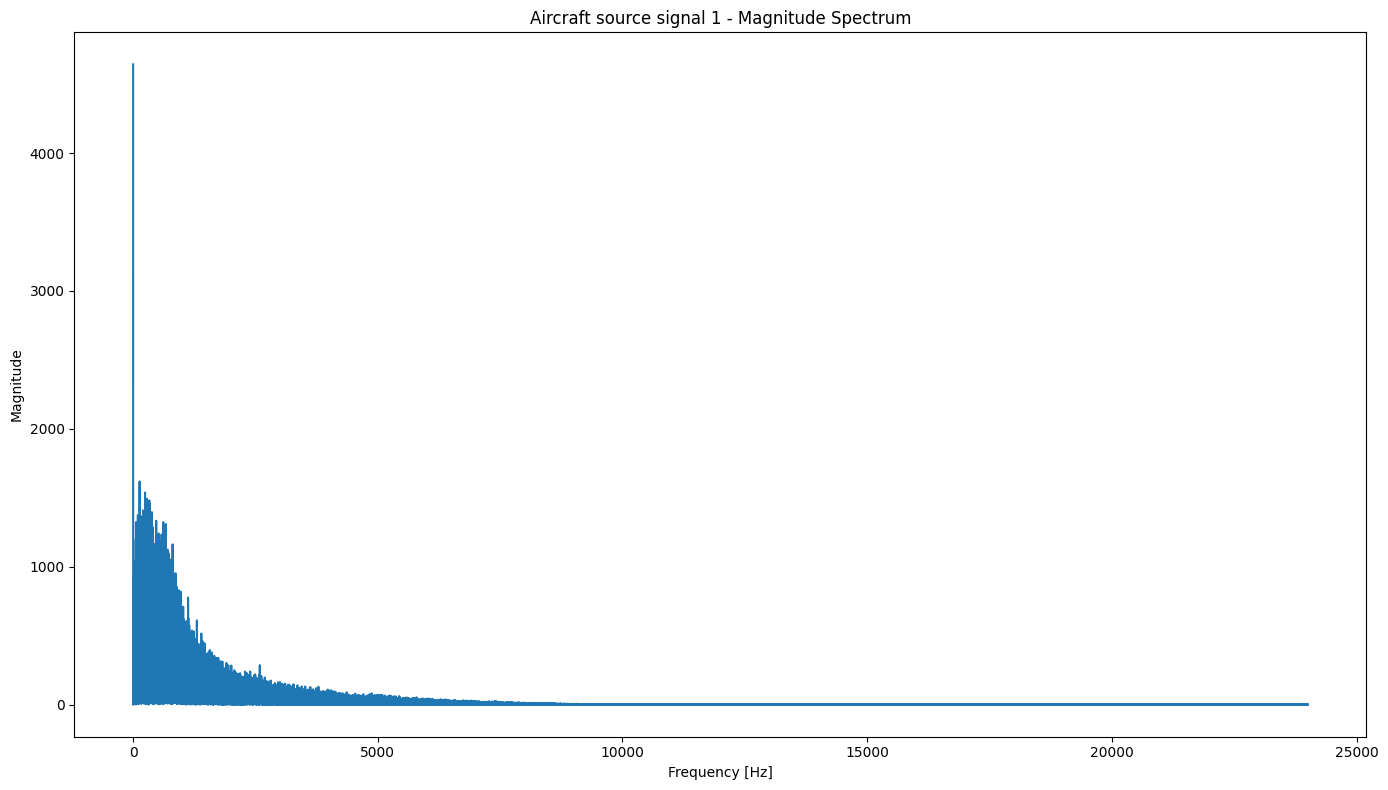

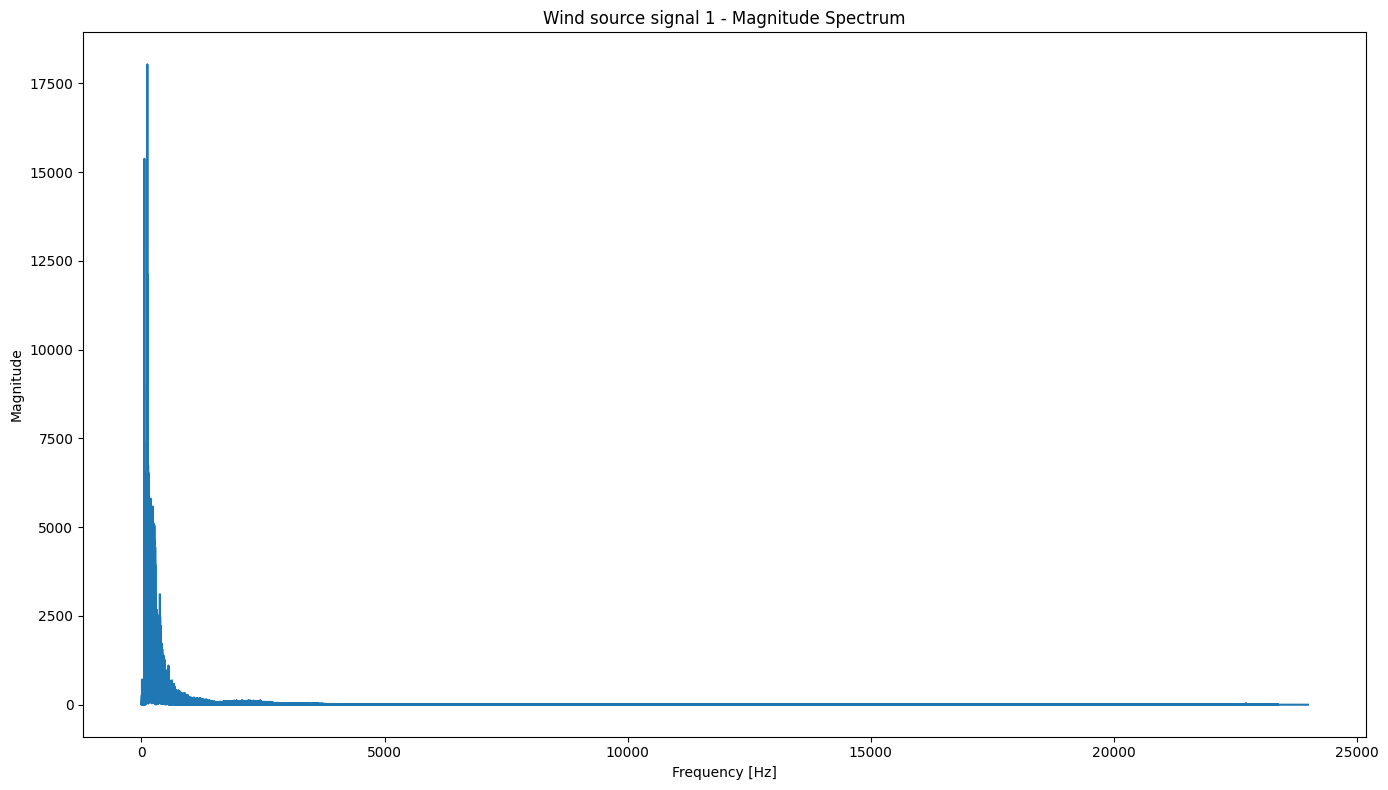

In [38]:
# Plot source signals

plot_waveforms(s1.reshape(-1,1), sr1, "Aircraft source signal")
plot_waveforms(s2.reshape(-1,1), sr2, "Wind source signal")

plot_fft(s1.reshape(-1,1), sr1, "Aircraft source signal")
plot_fft(s2.reshape(-1,1), sr1, "Wind source signal")

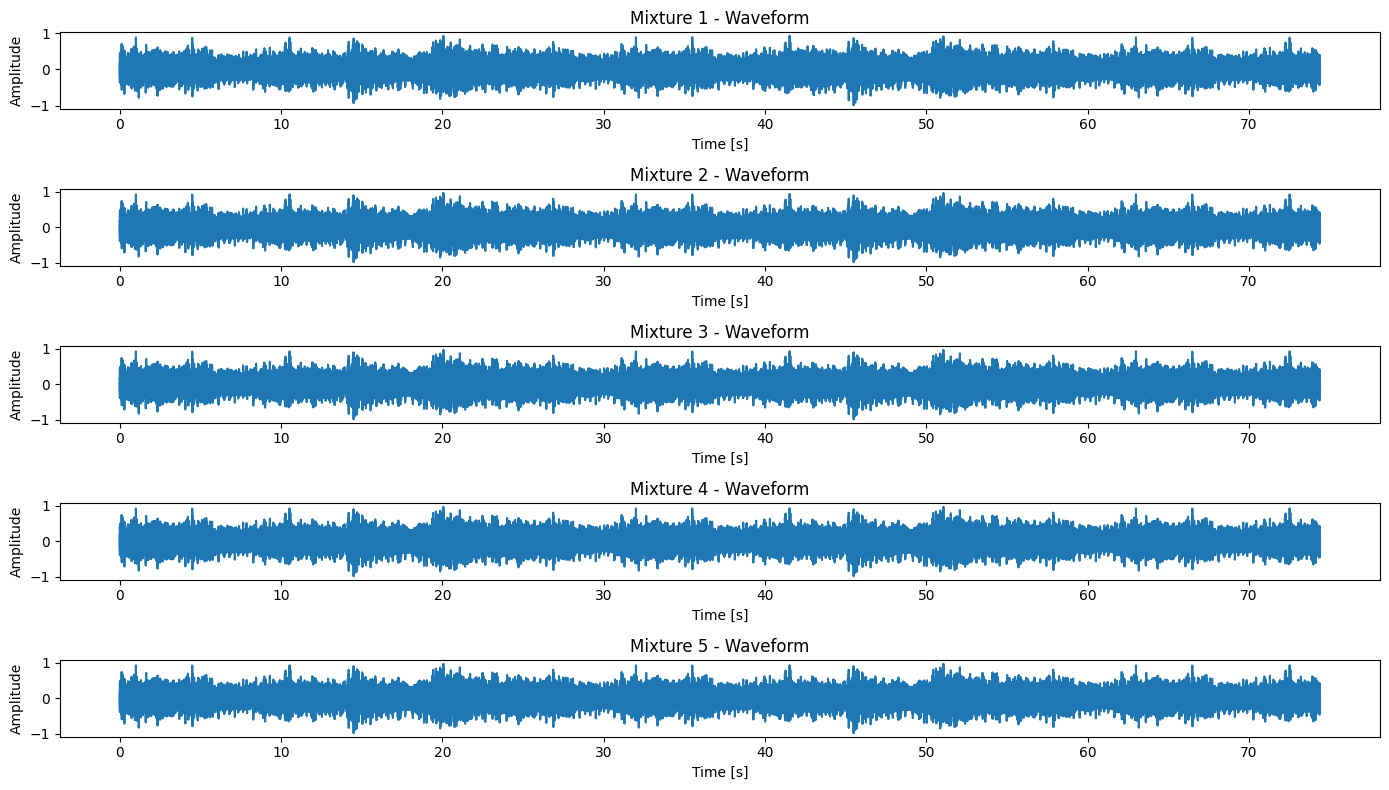

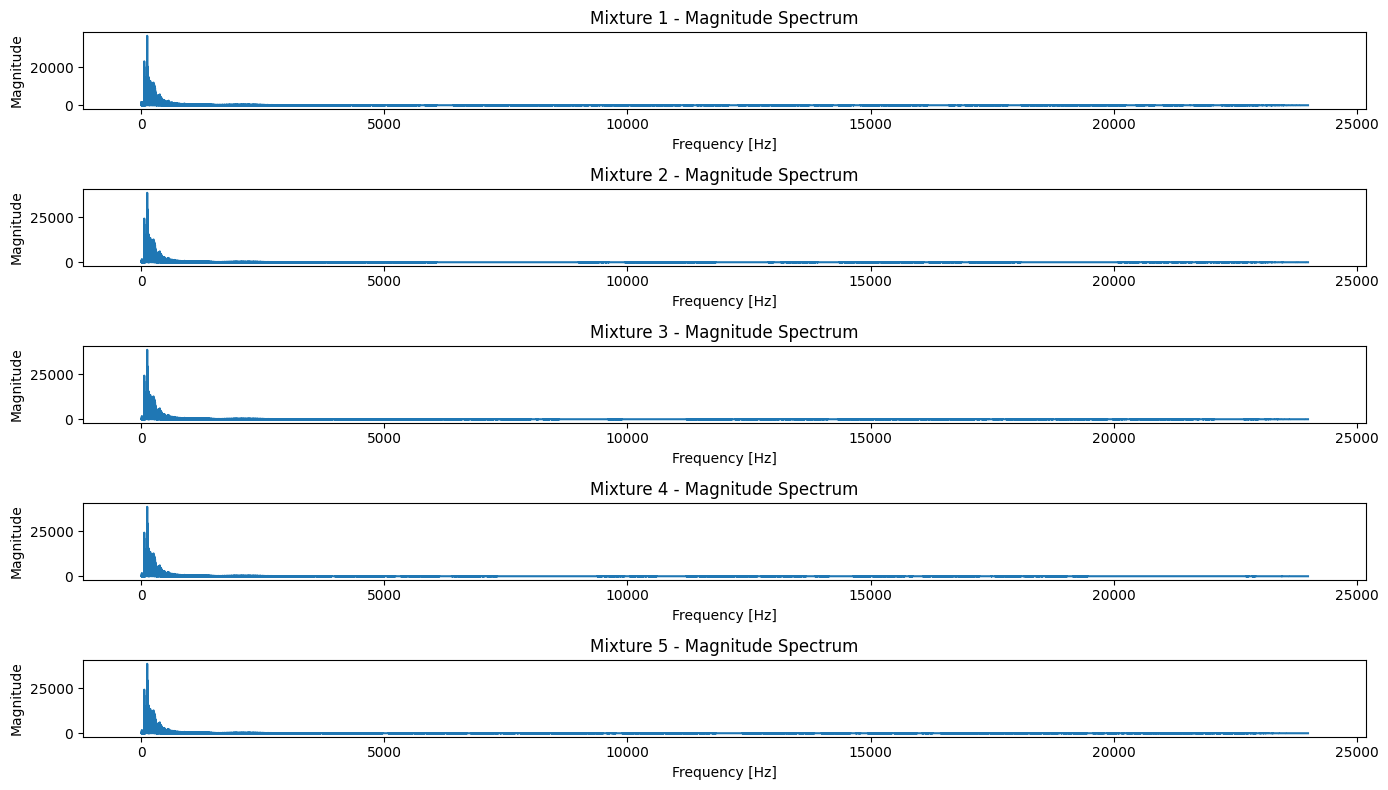

In [39]:
# Plot mixed signals

plot_waveforms(X.transpose(), sr, "Mixture")
plot_fft(X.transpose(), sr, "Mixture")